In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, KFold

from imblearn.over_sampling import SMOTE


import warnings
warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')

In [3]:
df = pd.read_csv("../../ml_data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

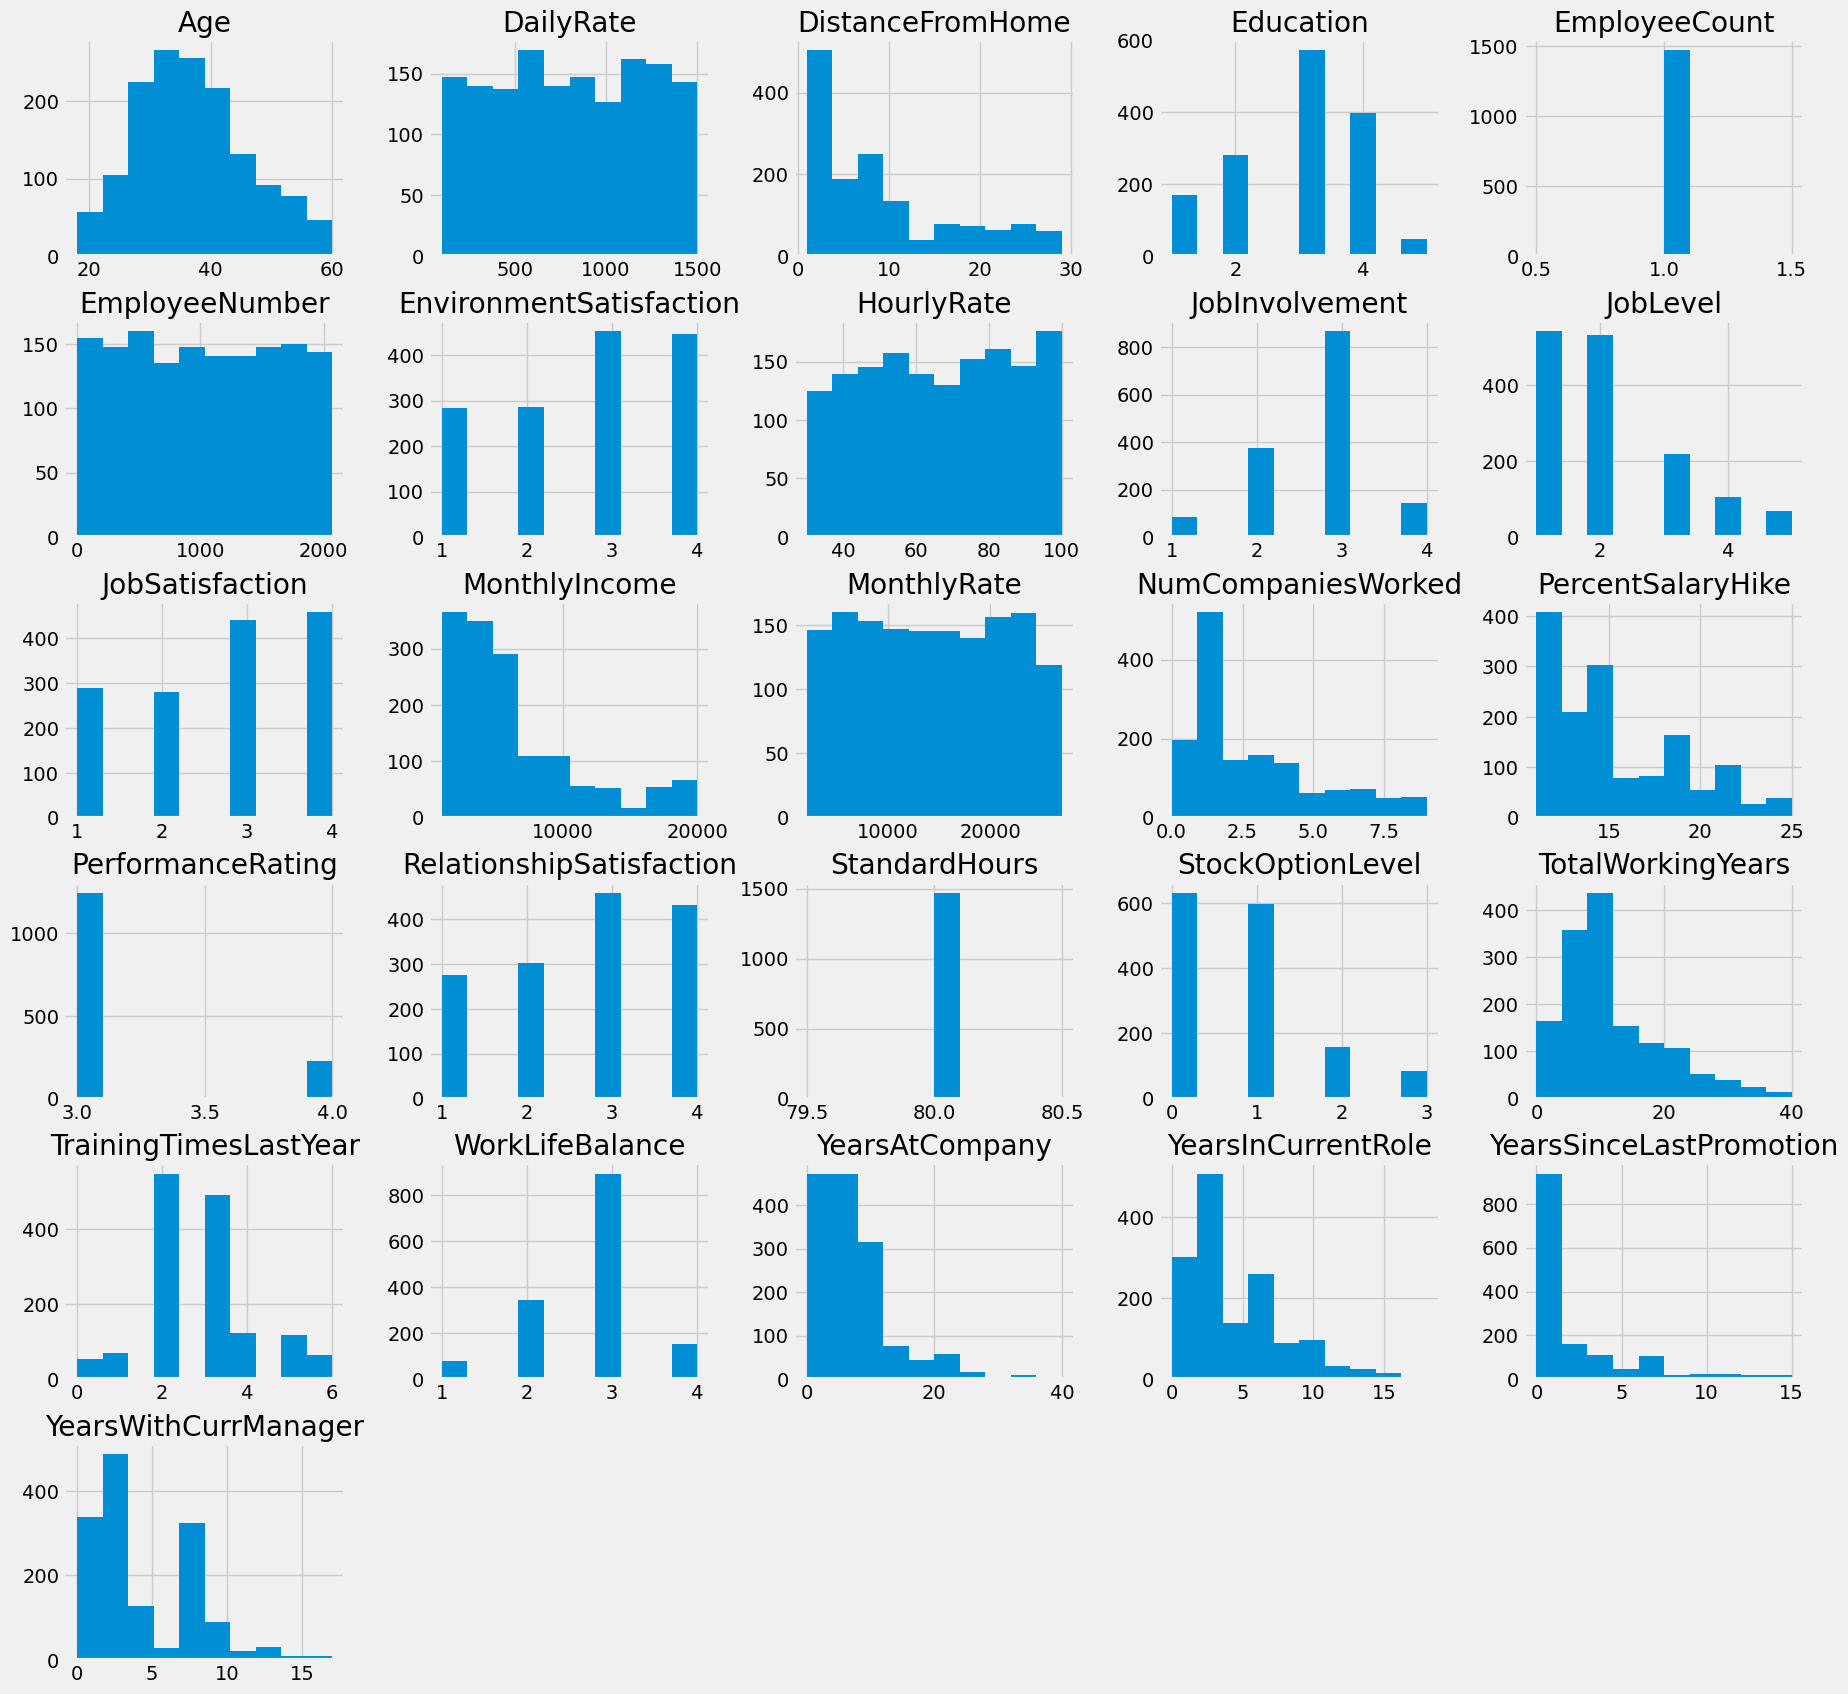

In [7]:
df.hist(figsize=(20, 20));

In [8]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis = 1, inplace = True)

In [9]:
# Encoding

for col in df.columns[1:]:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].nunique()}")

Attrition: 2
BusinessTravel: 3
Department: 3
EducationField: 6
Gender: 2
JobRole: 9
MaritalStatus: 3
OverTime: 2


In [10]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()

for col in df.columns[1: ]:
  if(df[col].dtype == 'object'):
    if len(list(df[col].unique())) == 2:
      df[col] = lb.fit_transform(df[col])

In [11]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2


In [12]:
# One-Hot Encoding

df = pd.get_dummies(df, columns = ['BusinessTravel', 'Department', 'MaritalStatus'], drop_first = True, dtype=int)

In [13]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,Life Sciences,2,0,94,3,...,6,4,0,5,0,1,0,1,0,1
1,49,0,279,8,1,Life Sciences,3,1,61,2,...,10,7,1,7,1,0,1,0,1,0
2,37,1,1373,2,2,Other,4,1,92,2,...,0,0,0,0,0,1,1,0,0,1
3,33,0,1392,3,4,Life Sciences,4,0,56,3,...,8,7,3,0,1,0,1,0,1,0
4,27,0,591,2,1,Medical,1,1,40,3,...,2,2,2,2,0,1,1,0,1,0


In [14]:
target = df["Attrition"]
X = df.drop("Attrition", axis=1)

In [15]:
target.value_counts(normalize=True)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=1, stratify=target)

In [17]:
df["JobRole"].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [18]:
import category_encoders as ce

In [19]:
ce_target = ce.TargetEncoder(cols=['EducationField', 'JobRole'])

In [20]:
X_train = ce_target.fit_transform(X_train, y_train)

In [21]:
X_test = ce_target.transform(X_test)

In [23]:
sm = SMOTE()

X_sm, y_sm = sm.fit_resample(X_train, y_train)
print("Distribution of target {}".format(y_sm.value_counts()))

Distribution of target Attrition
0    986
1    986
Name: count, dtype: int64


In [25]:
tree_clf = DecisionTreeClassifier(random_state=1)

In [28]:
kFold = KFold(n_splits=5)

cv_acc_results = cross_validate(tree_clf, X_sm, y_sm, cv=kFold, scoring='accuracy', return_train_score=True)

In [29]:
cv_acc_results['train_score'].mean()

np.float64(1.0)

In [30]:
cv_acc_results['test_score'].mean()

np.float64(0.8215318383345114)

#### Pre-Pruning

In [31]:
tree_clf = DecisionTreeClassifier(random_state=7, max_depth=10, min_samples_leaf=5, min_samples_split=10)

# Perform cross-validation on the classifier
cv_acc_results = cross_validate(tree_clf, X_sm, y_sm, cv=kFold, scoring='accuracy', return_train_score=True)

In [32]:
cv_acc_results['train_score'].mean()

np.float64(0.9238091449247058)

In [33]:
cv_acc_results['test_score'].mean()

np.float64(0.8027796697294866)

In [35]:
tree_clf = tree_clf.fit(X_sm, y_sm)
pred = tree_clf.predict(X_test)

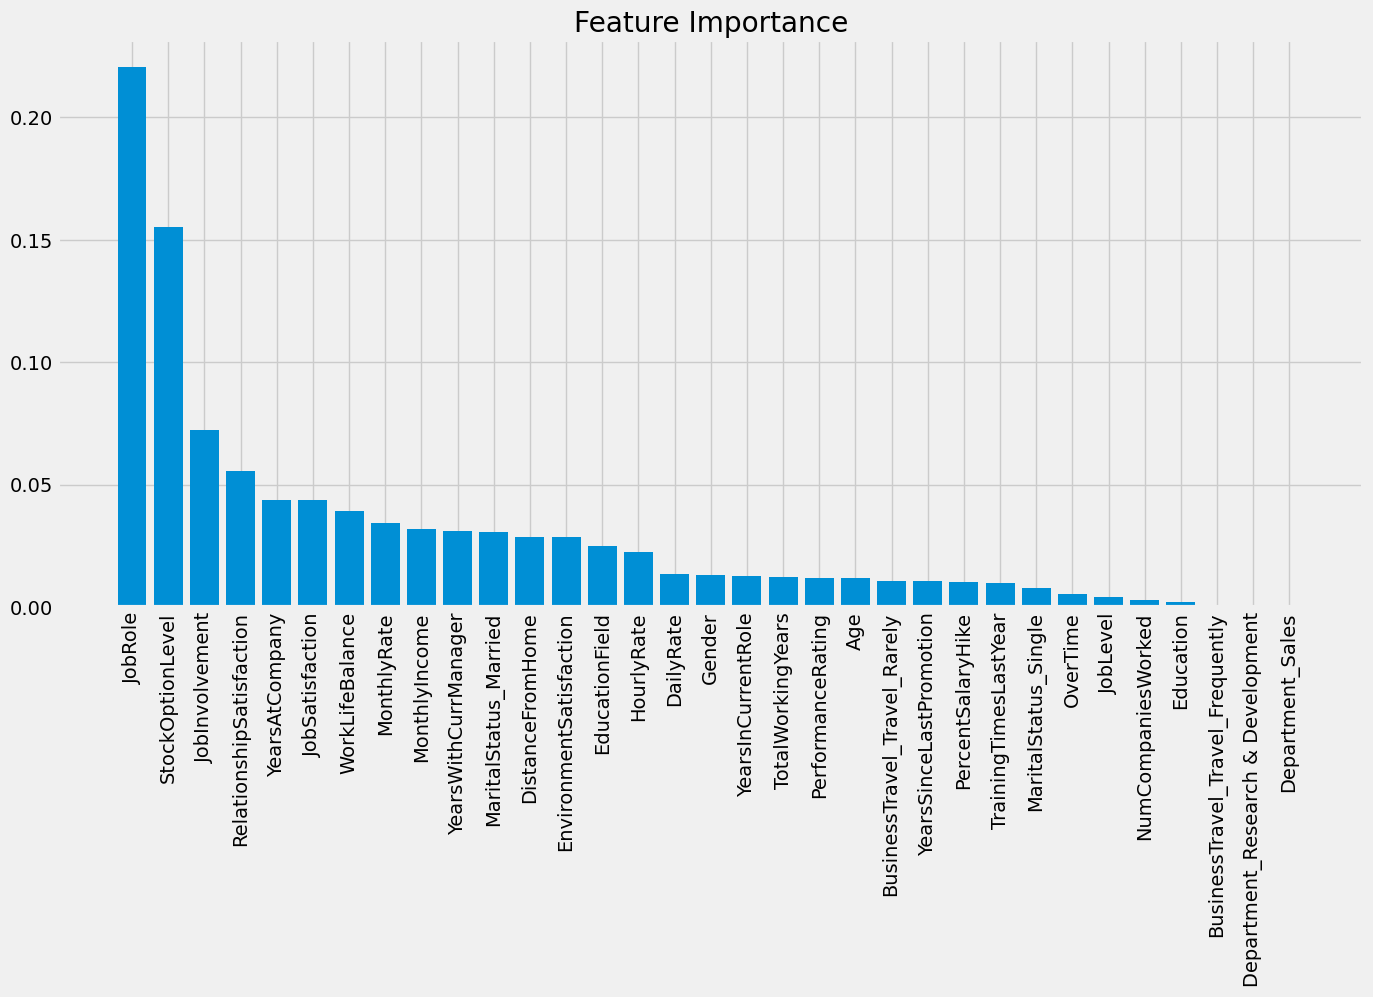

In [37]:
features = list(X_sm.columns)

importances = tree_clf.feature_importances_;
indices = np.argsort(importances)[::-1];  # Sort feature importances in descending order
names = [features[i] for i in indices];   # Rearrange feature names so they match the sorted feature importances

plt.figure(figsize=(15, 7));  # Create plot
plt.title("Feature Importance");  # Create plot title
plt.bar(range(len(features)), importances[indices]);  # Add bars
plt.xticks(range(len(features)), names, rotation=90);